# Setup

In [72]:
import json
import os

import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


In [73]:
with open(f'../data/debate_topics.json', 'r') as fp:
    topics = json.load(fp)

In [74]:
n = 10
topic_ix = 15
topic_nr = topic_ix + 1
proposition = list(topics.keys())[topic_nr]
proposition

'We should ban targeted online advertising on the basis of user profiles and demographics'

## Baseline

In [75]:
file_df = pd.DataFrame(os.listdir("./data/toxic_and_baseline_random_oss/"), columns=["Path"])
# remove '.ipynb_checkpoints'"
print(file_df.shape)
file_df = file_df.query("Path != '.ipynb_checkpoints'", engine="python")
print(file_df.shape)
file_df.head()

(1194, 1)
(1194, 1)


,Path
0,discussion_2_round_2_for_topic_27_neither_toxi...
1,discussion_3_round_8_for_topic_11_con_toxic_le...
2,discussion_25_round_15_for_topic_41_pro_toxic_...
3,discussion_8_round_2_for_topic_11_pro_toxic_le...
4,discussion_25_round_20_for_topic_41_pro_toxic_...


In [76]:
file_df["discussion"] = file_df["Path"].str.split("_round_").apply(lambda x: int(x[0].split("_")[1]))

In [77]:
file_df["round"] = file_df["Path"].str.split("_for_").apply(lambda x: int(x[0].split("_round_")[1]))

In [78]:
file_df["max_round_per_discussion"] = file_df.groupby("discussion")["round"].transform("max")

In [79]:
file_df = file_df.query("round == max_round_per_discussion")

In [80]:
file_df.shape

(41, 4)

In [81]:
file_df["discussion"] = file_df["discussion"].astype(int)

In [82]:
rounds_of_convergence = []
for path in file_df["Path"]:

    with open(f'../data/toxic_and_baseline_random_oss/' + path, 'r') as fp:
        debate = json.load(fp)

    # *2 because of pairs
    # +jx because it might be counterargument of round
    # +1 because there has been a previous round
    unfold_history = [
        ((ix)*(2) + jx + 1, content["next_answer"], content["agent"].split("_")[0])
        for ix, (name, contents) in enumerate(debate["discussion_history"].items()) 
        if name.startswith('Round') 
        for jx, content in enumerate(contents)
    ]
    rounds_until_convergence_by_discussion = pd.DataFrame(unfold_history, columns=["round", "argument", "procon"])\
        .query("argument == 'convinced'")\
        .sort_values("round", ascending=True).head(1)
    
    if len(rounds_until_convergence_by_discussion) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_discussion["round"].iloc[0],
                rounds_until_convergence_by_discussion["procon"].iloc[0] + " has been convinced"
            )
        )
        continue

    unfold_history = [
        ((ix)*(2) +2, content['state of discussion']) 
        if "state of discussion" in content.keys() else 
        ((ix)*(2) +2, content['state_of_discussion']) 
        for ix, (name, content) in enumerate(debate["moderators_history"].items()) 
        if name.startswith('after_')
    ]
    rounds_until_convergence_by_moderator = pd.DataFrame(unfold_history, columns=["round", "status"])\
        .query("status == 'agents are in agreement'")\
        .sort_values("round", ascending=True).head(1)["round"]

    if len(rounds_until_convergence_by_moderator) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_moderator.iloc[0],
                "moderator detected alignment"
            )
        )
        continue
    
    rounds_of_convergence.append(
        (None, None)
    )
    print("Oh")
        

Oh


In [83]:
file_df[["rounds_to_convergence", "reason_for_convergence"]] = rounds_of_convergence

In [84]:
file_df = file_df.query("rounds_to_convergence.notnull()")

In [85]:
file_df["rounds_to_convergence"].value_counts()

rounds_to_convergence
8.0     6
10.0    5
14.0    5
12.0    5
20.0    3
15.0    2
25.0    2
18.0    2
4.0     2
19.0    2
39.0    1
23.0    1
16.0    1
13.0    1
24.0    1
26.0    1
Name: count, dtype: int64

In [86]:
file_df["reason_for_convergence"].value_counts()

reason_for_convergence
moderator detected alignment    19
pro has been convinced          12
con has been convinced           9
Name: count, dtype: int64

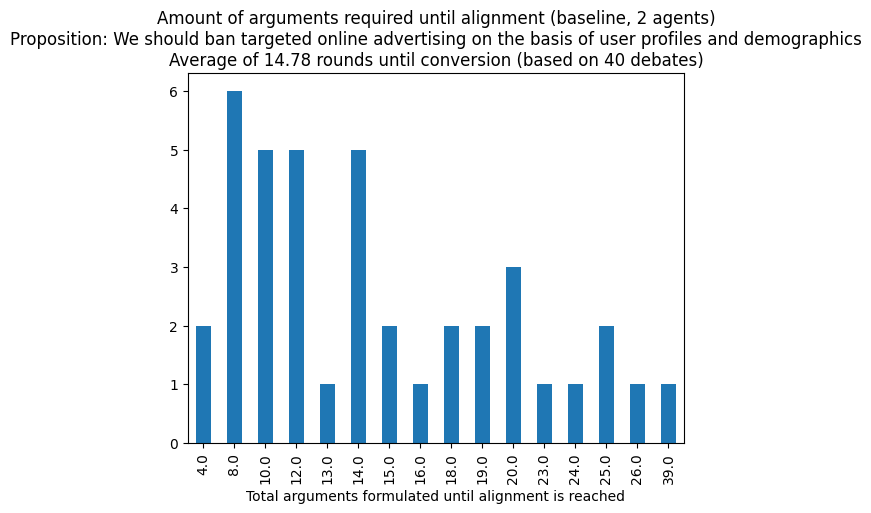

In [87]:
avg_conversion = file_df["rounds_to_convergence"].mean()

(file_df["rounds_to_convergence"])\
    .value_counts().sort_index()\
    .plot(
        kind="bar", 
        title=(
            f"Amount of arguments required until alignment (baseline, 2 agents)\n"
            f"Proposition: {proposition}\nAverage of {avg_conversion:.2f} rounds until "
            f"conversion (based on {len(file_df)} debates)"
        ),
        xlabel="Total arguments formulated until alignment is reached"
    );

In [88]:
file_df.to_csv(
    f"../data/evaluation mad/convergence_of_{len(file_df)}_baseline_discussions_topic_{topic_nr}_oss.csv",
    index=False
)

In [89]:
file_df["rounds_to_convergence"].std()

np.float64(6.944791444322011)

## Toxic

In [90]:
file_df = pd.DataFrame(os.listdir("./data/toxic_discussions/"), columns=["Path"])
# remove '.ipynb_checkpoints'"
print(file_df.shape)
file_df = file_df.query("Path != '.ipynb_checkpoints'", engine="python")
print(file_df.shape)
file_df.head()

FileNotFoundError: [Errno 2] No such file or directory: './data/toxic_discussions/'

In [20]:
file_df["discussion"] = file_df["Path"].str.split("_round_").apply(lambda x: int(x[0].split("_")[1]))

In [21]:
file_df["round"] = file_df["Path"].str.split("_for_").apply(lambda x: int(x[0].split("_round_")[1]))

In [22]:
file_df["toxicity_level"] = file_df["Path"].str.split("_level_").apply(lambda x: x[1].split(".json")[0])

In [23]:
file_df["max_round_per_discussion"] = file_df.groupby(["toxicity_level", "discussion"])["round"].transform("max")

In [24]:
file_df = file_df.query("round == max_round_per_discussion")

In [25]:
file_df.shape

(225, 5)

In [26]:
file_df

,Path,discussion,round,toxicity_level,max_round_per_discussion
1,discussion_7_round_9_for_topic_16_con_toxic_le...,7,9,mild,9
7,discussion_89_round_8_for_topic_16_con_toxic_l...,89,8,moderate,8
9,discussion_50_round_4_for_topic_16_con_toxic_l...,50,4,mild,4
13,discussion_67_round_5_for_topic_16_pro_toxic_l...,67,5,mild,5
25,discussion_11_round_31_for_topic_16_con_toxic_...,11,31,heavy,31
...,...,...,...,...,...
1106,discussion_79_round_3_for_topic_16_con_toxic_l...,79,3,moderate,3
1113,discussion_91_round_5_for_topic_16_pro_toxic_l...,91,5,moderate,5
1118,discussion_10_round_5_for_topic_16_con_toxic_l...,10,5,mild,5
1119,discussion_64_round_4_for_topic_16_pro_toxic_l...,64,4,moderate,4


In [27]:
rounds_of_convergence = []
for path in file_df["Path"]:
    # if not ready yet, skip the final discussion that has not been finished
    #if "discussion_62" in path:
    #    rounds_of_convergence.append((None, None))
    #    continue

    with open(f'./data/toxic_discussions/' + path, 'r') as fp:
        debate = json.load(fp)

    # *2 because of pairs
    # +jx because it might be counterargument of round
    # +1 because there has been a previous round
    unfold_history = [
        ((ix)*(2) + jx + 1, content["next_answer"], content["agent"].split("_")[0]) 
        for ix, (name, contents) in enumerate(debate["discussion_history"].items()) 
        if name.startswith('Round') for 
        jx, content in enumerate(contents)
    ]

    rounds_until_convergence_by_discussion = pd.DataFrame(unfold_history, columns=["round", "argument", "procon"])\
        .query("argument == 'convinced'")\
        .sort_values("round", ascending=True).assign(toxic_agent=debate["pro_or_con_toxic"]).head(1)
    
    if len(rounds_until_convergence_by_discussion) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_discussion["round"].iloc[0],
                rounds_until_convergence_by_discussion["procon"].iloc[0] + " has been convinced",
                rounds_until_convergence_by_discussion["toxic_agent"].iloc[0] + " has toxic behaviour",
            )
        )
        continue

    unfold_history = [
        ((ix)*(2) +2, content['state of discussion']) 
        if "state of discussion" in content.keys() else 
        ((ix)*(2) +2, content['state_of_discussion']) 
        for ix, (name, content) in enumerate(debate["moderators_history"].items()) 
        if name.startswith('after_')
    ]
    rounds_until_convergence_by_moderator = pd.DataFrame(unfold_history, columns=["round", "status"])\
        .query("status == 'agents are in agreement'")\
        .sort_values("round", ascending=True).assign(toxic_agent=debate["pro_or_con_toxic"]).head(1)

    if len(rounds_until_convergence_by_moderator) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_moderator["round"].iloc[0],
                "moderator detected alignment",
                rounds_until_convergence_by_moderator["toxic_agent"].iloc[0] + " has toxic behaviour",
            )
        )
        continue
    
    rounds_of_convergence.append(
        (None, None, None)
    )
    print("Oh")
        

Oh
Oh
Oh
Oh
Oh
Oh
Oh
Oh
Oh
Oh
Oh
Oh


In [28]:
file_df[["rounds_to_convergence", "reason_for_convergence", "which_agent_is_toxic"]] = rounds_of_convergence

In [29]:
file_df = file_df.query("rounds_to_convergence.notnull() & toxicity_level.isin(['mild', 'moderate'])", engine="python")

In [30]:
conversion_vc = file_df.groupby("toxicity_level")["rounds_to_convergence"].value_counts(dropna=False).unstack().T
conversion_vc

toxicity_level,mild,moderate
rounds_to_convergence,,
5.0,1.0,NaN
6.0,1.0,3.0
7.0,2.0,1.0
8.0,9.0,3.0
9.0,3.0,3.0
10.0,12.0,9.0
11.0,6.0,9.0
12.0,17.0,29.0
13.0,9.0,9.0


In [31]:
conversion_mean = file_df.groupby("toxicity_level")["rounds_to_convergence"].agg(["mean", "size"])
conversion_mean.columns = ["average conversion", "# debates"]
conversion_mean

,average conversion,# debates
toxicity_level,,
mild,12.0,91
moderate,12.257732,97


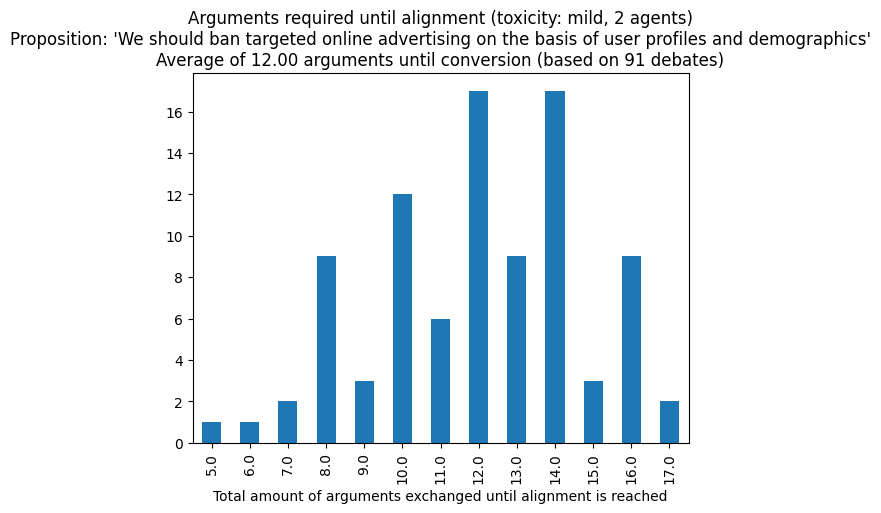

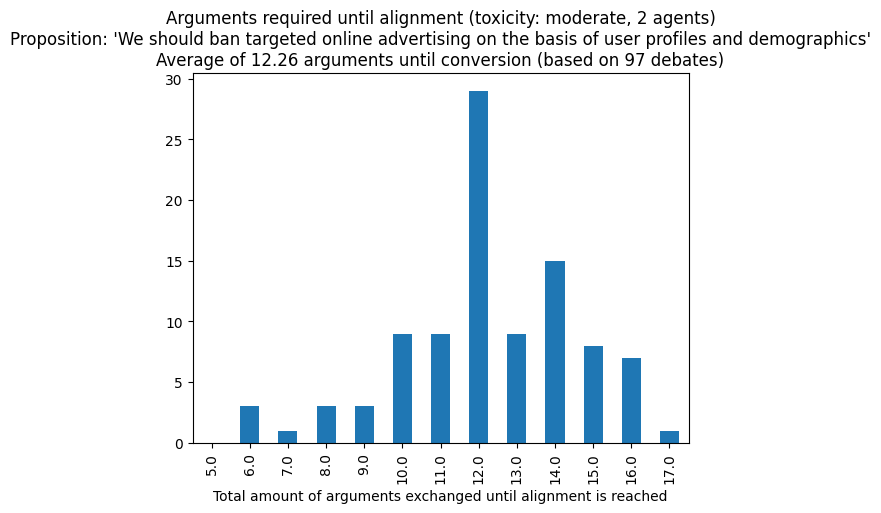

In [32]:
for toxicity_level in conversion_vc.columns:
    (conversion_vc[toxicity_level]).sort_index()\
    .plot(
        kind="bar", 
        title=(
            f"Arguments required until alignment (toxicity: {toxicity_level}, 2 agents)\n"
            f"Proposition: '{proposition}'\nAverage of {conversion_mean.loc[toxicity_level, 'average conversion']:.2f} "
            f"arguments until conversion (based on {int(conversion_mean.loc[toxicity_level, '# debates'])} debates)"
        ),
        xlabel="Total amount of arguments exchanged until alignment is reached"
    )
    plt.show();

In [33]:
file_df.to_csv(
    f"./data/evaluations/convergence_of_{len(file_df)}_toxic_discussions_topic_{topic_nr}.csv", 
    index=False
)

In [34]:
conversion_mean["average conversion"] / 9.84 # from first section

toxicity_level
mild        1.219512
moderate    1.245704
Name: average conversion, dtype: object

In [35]:
file_df.groupby("toxicity_level")["rounds_to_convergence"].agg(["mean", "var", "size"])

,mean,var,size
toxicity_level,,,
mild,12.0,7.311111,91
moderate,12.257732,5.464132,97


In [36]:
baseline = pd.read_csv(
    f"./data/evaluations/convergence_of_73_baseline_discussions_topic_16.csv"
)["rounds_to_convergence"].tolist()

In [37]:
mild = file_df.query("toxicity_level == 'mild'")["rounds_to_convergence"].tolist()
moderate = file_df.query("toxicity_level == 'moderate'")["rounds_to_convergence"].tolist()

In [38]:
print ("The t-statistic is %.3f and the p-value is %.3f (Alternative: unequal)." % stats.ttest_ind(baseline, mild, equal_var=False))

The t-statistic is -5.301 and the p-value is 0.000 (Alternative: unequal).


In [39]:
print ("The t-statistic is %.3f and the p-value is %.3f (Alternative: unequal)." % stats.ttest_ind(baseline, moderate, equal_var=False))

The t-statistic is -6.412 and the p-value is 0.000 (Alternative: unequal).


In [40]:
print ("The t-statistic is %.3f and the p-value is %.3f  (Alternative: unequal)." % stats.ttest_ind(moderate, mild, equal_var=False))

The t-statistic is 0.697 and the p-value is 0.487  (Alternative: unequal).


In [41]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        mild, moderate, equal_var=False, alternative="less")
)

The t-statistic is -0.697 and the p-value is 0.243  (Alternative: less).


## Random Topic

In [186]:
file_df = pd.DataFrame(os.listdir("../data/toxic_and_baseline_random_oss/"), columns=["Path"])
# remove '.ipynb_checkpoints'"
print(file_df.shape)
file_df = file_df.query("Path != '.ipynb_checkpoints'", engine="python")
print(file_df.shape)
file_df.head()

(1901, 1)
(1901, 1)


,Path
0,discussion_2_round_2_for_topic_27_neither_toxi...
1,discussion_3_round_8_for_topic_11_con_toxic_le...
2,discussion_25_round_15_for_topic_41_pro_toxic_...
3,discussion_8_round_2_for_topic_11_pro_toxic_le...
4,discussion_25_round_20_for_topic_41_pro_toxic_...


In [187]:
file_df["discussion"] = file_df["Path"].str.split("_round_").apply(lambda x: int(x[0].split("_")[1]))

In [188]:
file_df["round"] = file_df["Path"].str.split("_for_").apply(lambda x: int(x[0].split("_round_")[1]))

In [189]:
file_df["toxicity_level"] = file_df["Path"].str.split("_level_").apply(lambda x: x[1].split(".json")[0])

In [190]:
file_df["max_round_per_discussion"] = file_df.groupby(["toxicity_level", "discussion"])["round"].transform("max")

In [191]:
file_df = file_df.query("round == max_round_per_discussion")

In [192]:
file_df.shape

(185, 5)

In [193]:
file_df

,Path,discussion,round,toxicity_level,max_round_per_discussion
1,discussion_3_round_8_for_topic_11_con_toxic_le...,3,8,mild,8
13,discussion_24_round_34_for_topic_60_con_toxic_...,24,34,heavy,34
14,discussion_14_round_8_for_topic_26_con_toxic_l...,14,8,moderate,8
16,discussion_32_round_4_for_topic_31_pro_toxic_l...,32,4,mild,4
25,discussion_36_round_2_for_topic_11_neither_tox...,36,2,no,2
...,...,...,...,...,...
1879,discussion_23_round_8_for_topic_57_con_toxic_l...,23,8,moderate,8
1889,discussion_36_round_4_for_topic_11_pro_toxic_l...,36,4,moderate,4
1890,discussion_29_round_4_for_topic_62_neither_tox...,29,4,no,4
1891,discussion_40_round_3_for_topic_30_neither_tox...,40,3,no,3


In [194]:
rounds_of_convergence = []
for path in file_df["Path"]:
    # if not ready yet, skip the final discussion that has not been finished
    #if "discussion_62" in path:
    #    rounds_of_convergence.append((None, None))
    #    continue

    with open(f'../data/toxic_and_baseline_random_oss/' + path, 'r') as fp:
        debate = json.load(fp)

    # *2 because of pairs
    # +jx because it might be counterargument of round
    # +1 because there has been a previous round
    unfold_history = [
        ((ix)*(2) + jx + 1, content["next_answer"], content["agent"].split("_")[0]) 
        for ix, (name, contents) in enumerate(debate["discussion_history"].items()) 
        if name.startswith('Round') for 
        jx, content in enumerate(contents)
    ]

    rounds_until_convergence_by_discussion = pd.DataFrame(unfold_history, columns=["round", "argument", "procon"])\
        .query("argument == 'convinced'")\
        .sort_values("round", ascending=True).assign(toxic_agent=debate["pro_or_con_toxic"]).head(1)
    
    if len(rounds_until_convergence_by_discussion) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_discussion["round"].iloc[0],
                rounds_until_convergence_by_discussion["procon"].iloc[0] + " has been convinced",
                rounds_until_convergence_by_discussion["toxic_agent"].iloc[0] + " has toxic behaviour",
            )
        )
        continue

    unfold_history = [
        ((ix)*(2) +2, content['state of discussion']) 
        if "state of discussion" in content.keys() else 
        ((ix)*(2) +2, content['state_of_discussion']) 
        for ix, (name, content) in enumerate(debate["moderators_history"].items()) 
        if name.startswith('after_')
    ]
    rounds_until_convergence_by_moderator = pd.DataFrame(unfold_history, columns=["round", "status"])\
        .query("status == 'agents are in agreement'")\
        .sort_values("round", ascending=True).assign(toxic_agent=debate["pro_or_con_toxic"]).head(1)

    if len(rounds_until_convergence_by_moderator) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_moderator["round"].iloc[0],
                "moderator detected alignment",
                rounds_until_convergence_by_moderator["toxic_agent"].iloc[0] + " has toxic behaviour",
            )
        )
        continue
    
    rounds_of_convergence.append(
        (None, None, None)
    )
    print("Oh")
        

Oh
Oh


In [195]:
file_df[["rounds_to_convergence", "reason_for_convergence", "which_agent_is_toxic"]] = rounds_of_convergence

In [196]:
file_df = file_df.query("rounds_to_convergence.notnull() & toxicity_level.isin(['mild', 'moderate', 'no'])", engine="python")

In [197]:
conversion_vc = file_df.groupby("toxicity_level")["rounds_to_convergence"].value_counts(dropna=False).unstack().T
conversion_vc

toxicity_level,mild,moderate,no
rounds_to_convergence,,,
6.0,NaN,NaN,9.0
7.0,1.0,NaN,1.0
8.0,NaN,2.0,15.0
9.0,2.0,1.0,6.0
10.0,6.0,3.0,7.0
11.0,4.0,3.0,2.0
12.0,14.0,6.0,6.0
13.0,3.0,2.0,2.0
14.0,5.0,5.0,NaN


In [198]:
conversion_mean = file_df.groupby("toxicity_level")["rounds_to_convergence"].agg(["mean", "size"])
conversion_mean.columns = ["average conversion", "# debates"]
conversion_mean

,average conversion,# debates
toxicity_level,,
mild,13.918367,49
moderate,16.454545,44
no,9.040816,49


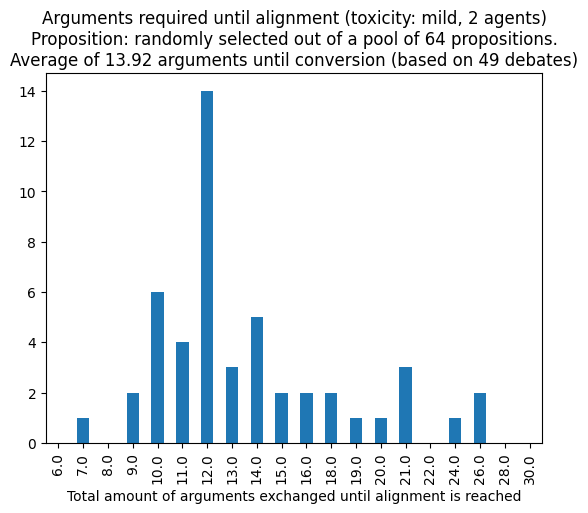

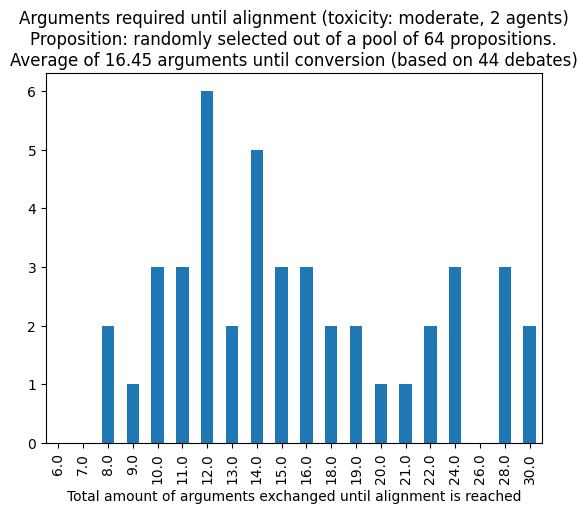

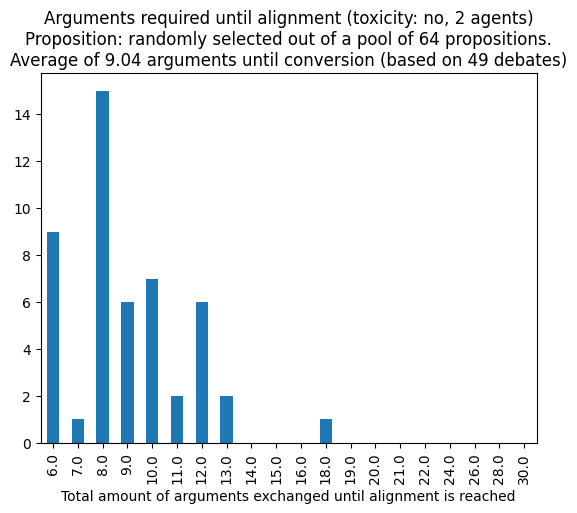

In [199]:
for toxicity_level in conversion_vc.columns:
    (conversion_vc[toxicity_level]).sort_index()\
    .plot(
        kind="bar", 
        title=(
            f"Arguments required until alignment (toxicity: {toxicity_level}, 2 agents)\n"
            f"Proposition: randomly selected out of a pool of 64 propositions.\nAverage of {conversion_mean.loc[toxicity_level, 'average conversion']:.2f} "
            f"arguments until conversion (based on {int(conversion_mean.loc[toxicity_level, '# debates'])} debates)"
        ),
        xlabel="Total amount of arguments exchanged until alignment is reached"
    )
    plt.show();

In [208]:
file_df.to_csv(
    f"../data/evaluation mad/convergence_of_{len(file_df)}_toxic_random_discussions_topic_{topic_nr}_oss.csv",
    index=False
)

In [209]:
conversion_mean["average conversion"] / conversion_mean["average conversion"].loc["no"]

toxicity_level
mild        1.539503
moderate    1.820029
no               1.0
Name: average conversion, dtype: object

In [210]:
file_df.groupby("toxicity_level")["rounds_to_convergence"].agg(["mean", "var", "size"])

,mean,var,size
toxicity_level,,,
mild,13.918367,19.326531,49
moderate,16.454545,38.207188,44
no,9.040816,5.873299,49


In [211]:
baseline = file_df.query("toxicity_level == 'no'")["rounds_to_convergence"].tolist()

In [212]:
mild = file_df.query("toxicity_level == 'mild'")["rounds_to_convergence"].tolist()
moderate = file_df.query("toxicity_level == 'moderate'")["rounds_to_convergence"].tolist()

In [213]:
print ("The t-statistic is %.3f and the p-value is %.3f (Alternative: unequal)." % stats.ttest_ind(
    baseline, mild, equal_var=False))

The t-statistic is -6.801 and the p-value is 0.000 (Alternative: unequal).


In [214]:
print ("The t-statistic is %.3f and the p-value is %.3f (Alternative: unequal)." % stats.ttest_ind(
    baseline, moderate, equal_var=False))

The t-statistic is -7.458 and the p-value is 0.000 (Alternative: unequal).


In [215]:
print ("The t-statistic is %.3f and the p-value is %.3f  (Alternative: unequal)." % stats.ttest_ind(
    moderate, mild, equal_var=False))

The t-statistic is 2.257 and the p-value is 0.027  (Alternative: unequal).


In [216]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        mild, moderate, equal_var=False, alternative="less")
)

The t-statistic is -2.257 and the p-value is 0.013  (Alternative: less).


In [217]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        baseline, moderate, equal_var=False, alternative="less")
)

The t-statistic is -7.458 and the p-value is 0.000  (Alternative: less).


In [218]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        baseline, mild, equal_var=False, alternative="less")
)

The t-statistic is -6.801 and the p-value is 0.000  (Alternative: less).
